In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(".."))
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path(os.path.abspath("."))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

In [2]:
RESEARCH_DATASET_DIR = (PROJECT_ROOT / "data" / "research_processed_smoke_auto").resolve()
RESEARCH_MODEL_DIR = (PROJECT_ROOT / "models" / "research_smoke_auto").resolve()
RESEARCH_RESULTS_DIR = (PROJECT_ROOT / "results" / "research_smoke_auto").resolve()

# 04 GPT

This notebook loads threshold-crossing anomaly candidates, builds compact GPT inputs, calls the OpenAI Responses API, parses structured JSON output, and compares AE-only vs AE+GPT decisions.

GPT is only used after anomaly score threshold crossing. The FiLM autoencoder remains the anomaly detector.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

from src.config import GPTConfig
from src.gpt_adjudicator import (
    adjudicate_anomaly,
    adjudicate_anomaly_records,
    build_window_summary,
    call_openai_responses_api,
    compare_ae_vs_gpt_decisions,
)
from src.utils import read_json

## Load Anomalous Windows Or Evaluation Results

In [4]:
cfg = GPTConfig(
    evaluation_dir=RESEARCH_RESULTS_DIR,
    output_dir=RESEARCH_RESULTS_DIR,
    max_records=100,
)

alerts = pd.read_csv(cfg.evaluation_dir / "realtime_alert_candidates.csv")
alerts = alerts.sort_values("anomaly_score", ascending=False).reset_index(drop=True)
alerts.head()

,window_id,container_id,machine_id,end_time,split,anomaly_score,threshold,score_over_threshold,feature_error_vector,top_feature_rank,...,predicted_label,event_id,realtime_step,alert_ready,gpt_triggered,gpt_label,gpt_severity,gpt_recommended_action,gpt_explanation,compact_anomaly_summary
0,107091,unknown_container,unknown_machine,107091,test,34.630360,4.428045,30.202315,"[0.73734050989151, 0.06782829761505127, 0.3532...","[3, 4, 7, 0, 2, 1, 5, 6]",...,1,-1,107091,True,True,critical,high,raise_alert,The score is far above threshold and the highe...,"{""window_id"": 107091, ""container_id"": ""unknown..."
1,113525,unknown_container,unknown_machine,113525,test,29.777863,4.428045,25.349818,"[1.0974605083465576, 0.041616491973400116, 0.2...","[3, 4, 0, 7, 2, 1, 5, 6]",...,1,-1,113525,True,True,critical,high,raise_alert,The score is far above threshold and the highe...,"{""window_id"": 113525, ""container_id"": ""unknown..."
2,293265,unknown_container,unknown_machine,293265,test,28.906368,4.428045,24.478323,"[1.8957717418670654, 0.040526922792196274, 0.3...","[3, 4, 0, 7, 2, 1, 6, 5]",...,1,-1,293265,True,True,critical,high,raise_alert,The score is far above threshold and the highe...,"{""window_id"": 293265, ""container_id"": ""unknown..."
3,319458,unknown_container,unknown_machine,319458,test,26.922892,4.428045,22.494847,"[0.4275738298892975, 0.015731675550341606, 0.2...","[3, 4, 7, 0, 2, 5, 1, 6]",...,1,-1,319458,True,True,critical,high,raise_alert,The score is far above threshold and the highe...,"{""window_id"": 319458, ""container_id"": ""unknown..."
4,305586,unknown_container,unknown_machine,305586,test,25.494186,4.428045,21.066142,"[1.7670140266418457, 0.038925282657146454, 0.2...","[3, 4, 0, 7, 2, 1, 6, 5]",...,1,-1,305586,True,True,critical,high,raise_alert,The score is far above threshold and the highe...,"{""window_id"": 305586, ""container_id"": ""unknown..."


## Build Compact GPT Input

In [5]:
sample_payload = alerts.iloc[0].to_dict() if len(alerts) > 0 else {}
sample_summary = build_window_summary(sample_payload) if sample_payload else {}
sample_summary

{'window_id': 107091,
 'container_id': 'unknown_container',
 'machine_id': 'unknown_machine',
 'split': 'test',
 'time_range': {'start_time': -1, 'end_time': 107091},
 'anomaly_score': 34.6303596496582,
 'threshold': 4.42804479598999,
 'score_over_threshold': 30.202314853668213,
 'top_k_features': ['mem_gps', 'mpki', 'disk_io', 'cpu_util', 'cpi'],
 'top_k_feature_errors': [271.9454345703125,
  3.0758872032165527,
  0.7980010509490967,
  0.73734050989151,
  0.3532046675682068],
 'feature_error_vector': [0.73734050989151,
  0.06782829761505127,
  0.3532046675682068,
  271.9454345703125,
  3.0758872032165527,
  0.03660806268453598,
  0.028569478541612625,
  0.7980010509490967],
 'context_summary': {'container_app_du': 'unknown',
  'container_status': 'unknown',
  'machine_status': 'unknown',
  'machine_failure_domain_1': 'unknown',
  'machine_failure_domain_2': 'unknown'},
 'recent_logs': [],
 'recent_events': []}

## Call OpenAI Responses API

In [6]:
if sample_summary:
    sample_decision, sample_meta = call_openai_responses_api(sample_summary, cfg)
else:
    sample_decision, sample_meta = {}, {}

sample_meta, sample_decision

({'used_fallback': True, 'reason': 'openai_package_not_installed'},
 {'label': 'critical',
  'severity': 'high',
  'explanation': 'The score is far above threshold and the highest reconstruction errors are in mem_gps, mpki, disk_io. This is consistent with an active high-severity runtime issue.',
  'recommended_action': 'raise_alert'})

## Parse Structured JSON Output

In [7]:
sample_decision

{'label': 'critical',
 'severity': 'high',
 'explanation': 'The score is far above threshold and the highest reconstruction errors are in mem_gps, mpki, disk_io. This is consistent with an active high-severity runtime issue.',
 'recommended_action': 'raise_alert'}

## Compare AE-only Vs AE+GPT Decisions

In [8]:
adjudication_summary = adjudicate_anomaly_records(
    prediction_csv_path=cfg.evaluation_dir / "window_level_predictions.csv",
    config=cfg,
    max_records=cfg.max_records,
)
adjudication_summary

{'gpt_adjudications_csv': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\results\\research_smoke_auto\\gpt_adjudications.csv',
 'gpt_adjudications_json': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\results\\research_smoke_auto\\gpt_adjudications.json',
 'comparison_csv': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\results\\research_smoke_auto\\ae_vs_gpt_comparison.csv',
 'comparison_json': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\results\\research_smoke_auto\\ae_vs_gpt_comparison.json',
 'records': [{'window_id': 107091,
   'container_id': 'unknown_container',
   'machine_id': 'unknown_machine',
   'end_time': 107091,
   'split': 'test',
   'anomaly_score': 34.6303596496582,
   'threshold': 4.42804479598999,
   'score_over_threshold': 30.202314853668213,
   'feature_error_vector': '[0.73734050989151, 0.06782829761505127, 0.3532046675682068, 271.9454345703125, 3.0758872032165527, 0.03660806268453598, 0.028569478541612625, 0.7980010509490967]',
   'top_feature_rank': '[3, 4, 7, 0

In [9]:
adjudications = pd.read_csv(cfg.output_dir / "gpt_adjudications.csv")
comparison = pd.read_csv(cfg.output_dir / "ae_vs_gpt_comparison.csv")

adjudications.head(), comparison.head()

(   window_id       container_id       machine_id  end_time split  \
 0     107091  unknown_container  unknown_machine    107091  test   
 1     113525  unknown_container  unknown_machine    113525  test   
 2     293265  unknown_container  unknown_machine    293265  test   
 3     319458  unknown_container  unknown_machine    319458  test   
 4     305586  unknown_container  unknown_machine    305586  test   
 
    anomaly_score  threshold  score_over_threshold  \
 0      34.630360   4.428045             30.202315   
 1      29.777863   4.428045             25.349818   
 2      28.906368   4.428045             24.478323   
 3      26.922892   4.428045             22.494847   
 4      25.494186   4.428045             21.066142   
 
                                 feature_error_vector  \
 0  [0.73734050989151, 0.06782829761505127, 0.3532...   
 1  [1.0974605083465576, 0.041616491973400116, 0.2...   
 2  [1.8957717418670654, 0.040526922792196274, 0.3...   
 3  [0.4275738298892975, 0.015

## Visualize GPT Decisions

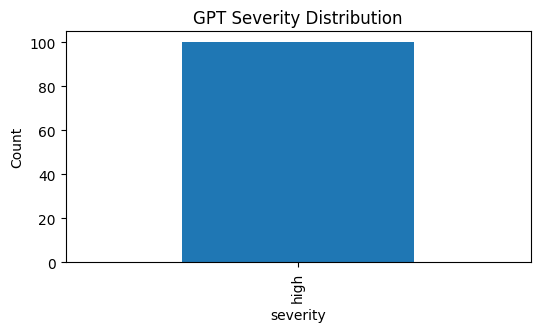

{'records': [{'window_id': 107091,
   'container_id': 'unknown_container',
   'machine_id': 'unknown_machine',
   'anomaly_score': 34.6303596496582,
   'ae_only_label': 'fault_candidate',
   'gpt_label': 'critical',
   'severity': 'high',
   'recommended_action': 'raise_alert',
   'explanation': 'The score is far above threshold and the highest reconstruction errors are in mem_gps, mpki, disk_io. This is consistent with an active high-severity runtime issue.'},
  {'window_id': 113525,
   'container_id': 'unknown_container',
   'machine_id': 'unknown_machine',
   'anomaly_score': 29.777862548828125,
   'ae_only_label': 'fault_candidate',
   'gpt_label': 'critical',
   'severity': 'high',
   'recommended_action': 'raise_alert',
   'explanation': 'The score is far above threshold and the highest reconstruction errors are in mem_gps, mpki, cpu_util. This is consistent with an active high-severity runtime issue.'},
  {'window_id': 293265,
   'container_id': 'unknown_container',
   'machine_

In [10]:
if len(adjudications) > 0:
    plt.figure(figsize=(6, 3))
    adjudications["severity"].value_counts().plot(kind="bar")
    plt.title("GPT Severity Distribution")
    plt.ylabel("Count")
    plt.show()

read_json(cfg.output_dir / "ae_vs_gpt_comparison.json")